In [1]:
import torch 
import os
import numpy as np
import torch.nn.functional as F
import pickle


from sklearn.manifold import TSNE
from torch.utils.data import Dataset, random_split
from torch import nn
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [3]:
# download dataset and split train and test set

cf10_training_data = datasets.CIFAR10(root = 'data', train = True, download= True, transform= transforms.ToTensor()) 

cf10_test_data = datasets.CIFAR10(root = 'Data', train = False, download= True, transform = transforms.ToTensor())


cf100_training_data = datasets.CIFAR100(root = 'data', train = True, download= True, transform= transforms.ToTensor()) 
cf100_test_data = datasets.CIFAR100(root = 'Data', train = False, download= True, transform = transforms.ToTensor())

In [4]:
base_folder = cf100_training_data.base_folder
root = cf100_training_data.root
file_path = os.path.join(root, base_folder, 'train')

with open(file_path, 'rb')as f:
    entry =pickle.load(f, encoding = 'latin1')
    cf100_training_data.targets = entry['coarse_labels']

file_path_test = os.path.join(root, base_folder, 'test')
with open(file_path_test, 'rb') as f:
    entry_test = pickle.load(f, encoding='latin1')
    cf100_test_data.targets = entry_test['coarse_labels']

In [5]:
#Splitting Logic
train_size = 40000
val_size = 10000

# print(len(cf100_training_data))

cf10_train_subset, cf10_val_subset = random_split(cf10_training_data, [train_size,val_size])
#cf100_val_data = random_split(cf100_training_data, [len(cf100_training_data)*0.8, len(cf100_training_data)*0.2])

In [6]:
print(1)
training_loader = torch.utils.data.DataLoader(cf10_train_subset, batch_size=32, shuffle=True)
validation_loader = torch.utils.data.DataLoader(cf10_val_subset, batch_size=32, shuffle=False)
#testing_loader = torch.utils.data.DataLoader(cf10_test_data, batch_size=32, shuffle=False)

1


In [7]:
class LesNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,6,5,1)
        self.conv2 = nn.Conv2d(6, 16, 5, 1)

        self.fc1 = nn.Linear(5*5*16, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')

    def forward(self, X):
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X, (2,2))
        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, (2,2))
        X = X.flatten(1)

        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return X
        
model_1 = LesNet().to(device)

In [8]:
# model 2

class Model2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,6,5,1)
        self.conv2 = nn.Conv2d(6, 16, 5, 1)

        self.fc1 = nn.Linear(5*5*16, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

        #add dropuot 
        #self.dropout = nn.Dropout2d(p = 0.3) # 30% chance to be 0

        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu') #different relu

    def forward(self, X):
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X, (2,2))
        X = F.dropout2d(X, p = 0.3)  #add dropuot 

        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, (2,2))
        X = F.dropout2d(X, p = 0.3)  #add dropuot 
        
        X = X.flatten(1)

        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return X

model_2 = Model2().to(device)

In [9]:
# model 3

class Model3(nn.Module): #Batch Normalization
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,6,5,1)
        self.bn1 = nn.BatchNorm2d(6)
        self.conv2 = nn.Conv2d(6, 16, 5, 1)
        self.bn2 = nn.BatchNorm2d(16)
        

        self.fc1 = nn.Linear(5*5*16, 120)
        self.bn3 = nn.BatchNorm1d(120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

      

        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu') #different relu

    def forward(self, X):
        X = F.relu(self.bn1(self.conv1(X)))
        X = F.max_pool2d(X, (2,2))
        

        X = F.relu(self.bn2(self.conv2(X)))
        X = F.max_pool2d(X, (2,2))
       

        X = X.flatten(1)

        X = F.relu(self.bn3(self.fc1(X)))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return X

model_3 = Model3().to(device)

In [10]:
#Train for each epoch
def train_one_epoch(model, loader,optimizer, criterion):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for inputs, label in loader:
        if torch.cuda.is_available():
                inputs, label = inputs.cuda(), label.cuda()
                model.cuda()
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, label)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += label.size(0)
        correct += predicted.eq(label).sum().item()

    average_loss = running_loss / len(loader)
    
    accuracy = correct/ total * 100
    return average_loss, accuracy

In [11]:
#validate each epoch
def validate(model, loader, criterion):
    model.eval() #Set model to eval mode 
    running_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, label in loader:
            if torch.cuda.is_available():
                inputs, label = inputs.cuda(), label.cuda()
                model.cuda()
            outputs = model(inputs)
            loss = criterion(outputs, label)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += label.size(0)
            correct += predicted.eq(label).sum().item()

        average_loss = running_loss / len(loader)
        accuracy = correct/ total * 100
        return average_loss, accuracy

            

In [12]:
def run_full_training_validate(model, train_loader, val_loader, epochs=20):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    history = {"training_loss": [], "training_accuracy": [], "validation_loss": [], "validation_accuracy": []}
    print("---Training and Validation has started---")
    for epoch in range(epochs):
        train_loss, train_accuracy = train_one_epoch(model, train_loader, optimizer, criterion)
        print(f"Epoch {epoch+1}, Training Loss : {train_loss}, Training Accuracy: {train_accuracy}")
        val_loss, val_accuracy = validate(model, val_loader, criterion)
        print(f"Epoch {epoch+1}, Validation Loss : {val_loss}, Validation Accuracy: {val_accuracy}")

        history['training_loss'].append(train_loss)
        history['training_accuracy'].append(train_accuracy)
        history['validation_loss'].append(val_loss)
        history['validation_accuracy'].append(val_accuracy)

    print('---Training and Validation has ended---')
    return history

In [35]:
history_1 = run_full_training_validate(model_1, training_loader, validation_loader)

---Training and Validation has started---
Epoch 1, Training Loss : 1.6201579973220825, Training Accuracy: 40.97
Epoch 1, Validation Loss : 1.4768790174216126, Validation Accuracy: 46.42
Epoch 2, Training Loss : 1.36428519449234, Training Accuracy: 50.79
Epoch 2, Validation Loss : 1.3144250750160826, Validation Accuracy: 52.580000000000005
Epoch 3, Training Loss : 1.260882677936554, Training Accuracy: 55.0875
Epoch 3, Validation Loss : 1.304749010660397, Validation Accuracy: 53.87
Epoch 4, Training Loss : 1.179473352766037, Training Accuracy: 57.96750000000001
Epoch 4, Validation Loss : 1.231318805926143, Validation Accuracy: 56.28999999999999
Epoch 5, Training Loss : 1.1140336755752565, Training Accuracy: 60.415
Epoch 5, Validation Loss : 1.2098900363468135, Validation Accuracy: 57.74
Epoch 6, Training Loss : 1.0559918339729308, Training Accuracy: 62.65500000000001
Epoch 6, Validation Loss : 1.2000383009164097, Validation Accuracy: 57.489999999999995
Epoch 7, Training Loss : 1.00317897

In [36]:
history_2 = run_full_training_validate(model_2, training_loader, validation_loader)

---Training and Validation has started---
Epoch 1, Training Loss : 1.9802708170890808, Training Accuracy: 27.755000000000003
Epoch 1, Validation Loss : 1.7890414574656623, Validation Accuracy: 35.010000000000005
Epoch 2, Training Loss : 1.7337473290443421, Training Accuracy: 37.385000000000005
Epoch 2, Validation Loss : 1.7184031302936542, Validation Accuracy: 37.51
Epoch 3, Training Loss : 1.6596298586845397, Training Accuracy: 40.3525
Epoch 3, Validation Loss : 1.6435562935880959, Validation Accuracy: 39.83
Epoch 4, Training Loss : 1.6076161884307862, Training Accuracy: 42.017500000000005
Epoch 4, Validation Loss : 1.620397787124585, Validation Accuracy: 41.49
Epoch 5, Training Loss : 1.5767790838241578, Training Accuracy: 43.5775
Epoch 5, Validation Loss : 1.6073372520196934, Validation Accuracy: 41.88
Epoch 6, Training Loss : 1.561701597738266, Training Accuracy: 43.614999999999995
Epoch 6, Validation Loss : 1.5784879071643938, Validation Accuracy: 42.92
Epoch 7, Training Loss : 1.

In [37]:
history_3 = run_full_training_validate(model_3, training_loader, validation_loader)

---Training and Validation has started---
Epoch 1, Training Loss : 0.5664930084347725, Training Accuracy: 79.7525
Epoch 1, Validation Loss : 1.2675914063621252, Validation Accuracy: 62.370000000000005
Epoch 2, Training Loss : 0.5512214888095855, Training Accuracy: 80.3425
Epoch 2, Validation Loss : 1.248807466068207, Validation Accuracy: 63.39
Epoch 3, Training Loss : 0.5370986362993717, Training Accuracy: 80.74
Epoch 3, Validation Loss : 1.306686742427631, Validation Accuracy: 62.33
Epoch 4, Training Loss : 0.5236753144025803, Training Accuracy: 81.415
Epoch 4, Validation Loss : 1.3160976198153755, Validation Accuracy: 62.12
Epoch 5, Training Loss : 0.5087927503526211, Training Accuracy: 81.7625
Epoch 5, Validation Loss : 1.3818319649361193, Validation Accuracy: 61.18
Epoch 6, Training Loss : 0.5029361302852631, Training Accuracy: 81.955
Epoch 6, Validation Loss : 1.3458959368852, Validation Accuracy: 62.36000000000001
Epoch 7, Training Loss : 0.49232042891979216, Training Accuracy: 8

In [16]:
# save all models

torch.save(model_1.state_dict(), 'cifar10_model1.pth')
torch.save(model_2.state_dict(), 'cifar10_model2.pth')
torch.save(model_3.state_dict(), 'cifar10_model3.pth')

print('models save')

models save


In [17]:
model_1 = LesNet()
model_1.load_state_dict(torch.load('cifar10_model1.pth'))

model_1.to(device)
model_1.eval()


model_2 = Model2()
model_2.load_state_dict(torch.load('cifar10_model2.pth'))

model_2.to(device)
model_2.eval()


model_3 = Model3()
model_3.load_state_dict(torch.load('cifar10_model3.pth'))

model_3.to(device)
model_3.eval()

Model3(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (bn1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (bn3): BatchNorm1d(120, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [18]:
#task 4  Current choice: model3(batch normalization) 
cf100_train_subset, cf100_val_subset = random_split(cf100_training_data, [train_size,val_size])

training_loader_cf100 = torch.utils.data.DataLoader(cf100_train_subset, batch_size=32, shuffle=True)
validation_loader_cf100 = torch.utils.data.DataLoader(cf100_val_subset, batch_size=32, shuffle=False)



In [19]:
class Model3_cf100(nn.Module): #it should be cf100 bruh
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,6,5,1)
        self.bn1 = nn.BatchNorm2d(6)
        self.conv2 = nn.Conv2d(6, 16, 5, 1)
        self.bn2 = nn.BatchNorm2d(16)
        

        self.fc1 = nn.Linear(5*5*16, 120)
        self.bn3 = nn.BatchNorm1d(120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 20)

      

        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu') #different relu

    def forward(self, X):
        X = F.relu(self.bn1(self.conv1(X)))
        X = F.max_pool2d(X, (2,2))
        

        X = F.relu(self.bn2(self.conv2(X)))
        X = F.max_pool2d(X, (2,2))
       

        X = X.flatten(1)

        X = F.relu(self.bn3(self.fc1(X)))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return X

model_3_cf100 = Model3_cf100().to(device)

In [20]:
history_cf100_1 = run_full_training_validate(model_3_cf100, training_loader_cf100, validation_loader_cf100)

---Training and Validation has started---
Epoch 1, Training Loss : 2.4360925182342528, Training Accuracy: 25.3525
Epoch 1, Validation Loss : 2.2463712981714608, Validation Accuracy: 30.580000000000002
Epoch 2, Training Loss : 2.1330210216522216, Training Accuracy: 34.095
Epoch 2, Validation Loss : 2.1201290570128077, Validation Accuracy: 34.589999999999996
Epoch 3, Training Loss : 1.9988818585395813, Training Accuracy: 38.0175
Epoch 3, Validation Loss : 2.109074432628985, Validation Accuracy: 35.52
Epoch 4, Training Loss : 1.8989727952957154, Training Accuracy: 40.949999999999996
Epoch 4, Validation Loss : 2.039059343429419, Validation Accuracy: 37.26
Epoch 5, Training Loss : 1.8252289924621583, Training Accuracy: 43.025000000000006
Epoch 5, Validation Loss : 1.999516751438665, Validation Accuracy: 38.3
Epoch 6, Training Loss : 1.762743092250824, Training Accuracy: 45.082499999999996
Epoch 6, Validation Loss : 1.9789180329051643, Validation Accuracy: 40.11
Epoch 7, Training Loss : 1.71

In [21]:
torch.save(model_3_cf100.state_dict(), 'cf100_model3.pth')
print('models save')

models save


In [22]:
model_3_cf100 = Model3_cf100()
model_3_cf100.load_state_dict(torch.load('cf100_model3.pth'))
model_3_cf100.to(device)
model_3_cf100.eval()

Model3_cf100(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (bn1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (bn3): BatchNorm1d(120, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=20, bias=True)
)

In [23]:
def run_full_training_validate_2(model, train_loader, val_loader, epochs=20):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

    history = {"training_loss": [], "training_accuracy": [], "validation_loss": [], "validation_accuracy": []}
    print("---Training and Validation has started---")
    for epoch in range(epochs):
        train_loss, train_accuracy = train_one_epoch(model, train_loader, optimizer, criterion)
        print(f"Epoch {epoch+1}, Training Loss : {train_loss}, Training Accuracy: {train_accuracy}")
        val_loss, val_accuracy = validate(model, val_loader, criterion)
        print(f"Epoch {epoch+1}, Validation Loss : {val_loss}, Validation Accuracy: {val_accuracy}")

        history['training_loss'].append(train_loss)
        history['training_accuracy'].append(train_accuracy)
        history['validation_loss'].append(val_loss)
        history['validation_accuracy'].append(val_accuracy)

    print('---Training and Validation has ended---')
    return history

In [24]:
CIFAR10_pretrained = model_3_cf100
CIFAR10_pretrained.fc3 = nn.Linear(84, 10).to(device)
history_pretrained = run_full_training_validate_2(
    CIFAR10_pretrained, 
    training_loader,   
    validation_loader, 
    epochs=20
)


---Training and Validation has started---
Epoch 1, Training Loss : 1.4708179927825928, Training Accuracy: 46.7275
Epoch 1, Validation Loss : 1.3020890210383236, Validation Accuracy: 52.88
Epoch 2, Training Loss : 1.2223542255401612, Training Accuracy: 56.169999999999995
Epoch 2, Validation Loss : 1.21269043527853, Validation Accuracy: 56.3
Epoch 3, Training Loss : 1.1333269251823426, Training Accuracy: 59.68750000000001
Epoch 3, Validation Loss : 1.1420574590040091, Validation Accuracy: 59.13
Epoch 4, Training Loss : 1.0664106462478637, Training Accuracy: 62.27
Epoch 4, Validation Loss : 1.1249934926200598, Validation Accuracy: 60.24
Epoch 5, Training Loss : 1.0151491138458253, Training Accuracy: 63.965
Epoch 5, Validation Loss : 1.0786788973945398, Validation Accuracy: 61.89
Epoch 6, Training Loss : 0.9703008781433106, Training Accuracy: 65.4825
Epoch 6, Validation Loss : 1.1199693976880642, Validation Accuracy: 60.419999999999995
Epoch 7, Training Loss : 0.9338978073596954, Training 

In [25]:
from sklearn.metrics import confusion_matrix, classification_report

def get_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return all_labels, all_preds

In [26]:
testing_loader = torch.utils.data.DataLoader(cf10_test_data, batch_size=32, shuffle=False)

In [27]:
labels_best, preds_best = get_predictions(model_3, testing_loader)
labels_pretrained, preds_pretrained = get_predictions(CIFAR10_pretrained, testing_loader)

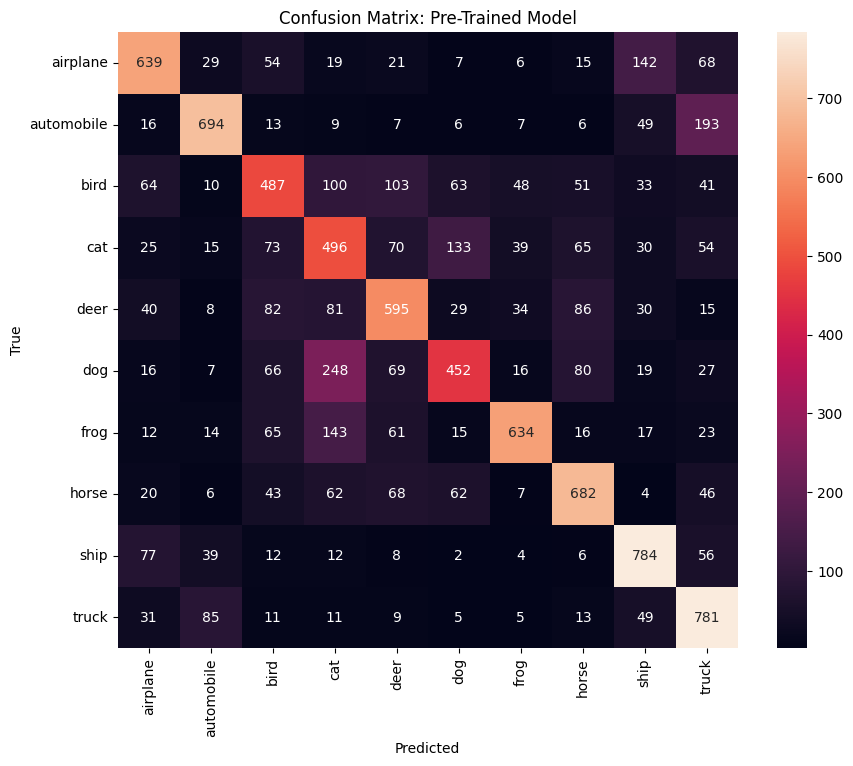

In [28]:
import seaborn as sns
cm = confusion_matrix(labels_pretrained, preds_pretrained)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=cf10_training_data.classes, yticklabels=cf10_training_data.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix: Pre-Trained Model')
plt.show()

In [29]:
cr = classification_report(labels_pretrained, preds_pretrained)
print(cr)

              precision    recall  f1-score   support

           0       0.68      0.64      0.66      1000
           1       0.77      0.69      0.73      1000
           2       0.54      0.49      0.51      1000
           3       0.42      0.50      0.45      1000
           4       0.59      0.59      0.59      1000
           5       0.58      0.45      0.51      1000
           6       0.79      0.63      0.70      1000
           7       0.67      0.68      0.68      1000
           8       0.68      0.78      0.73      1000
           9       0.60      0.78      0.68      1000

    accuracy                           0.62     10000
   macro avg       0.63      0.62      0.62     10000
weighted avg       0.63      0.62      0.62     10000



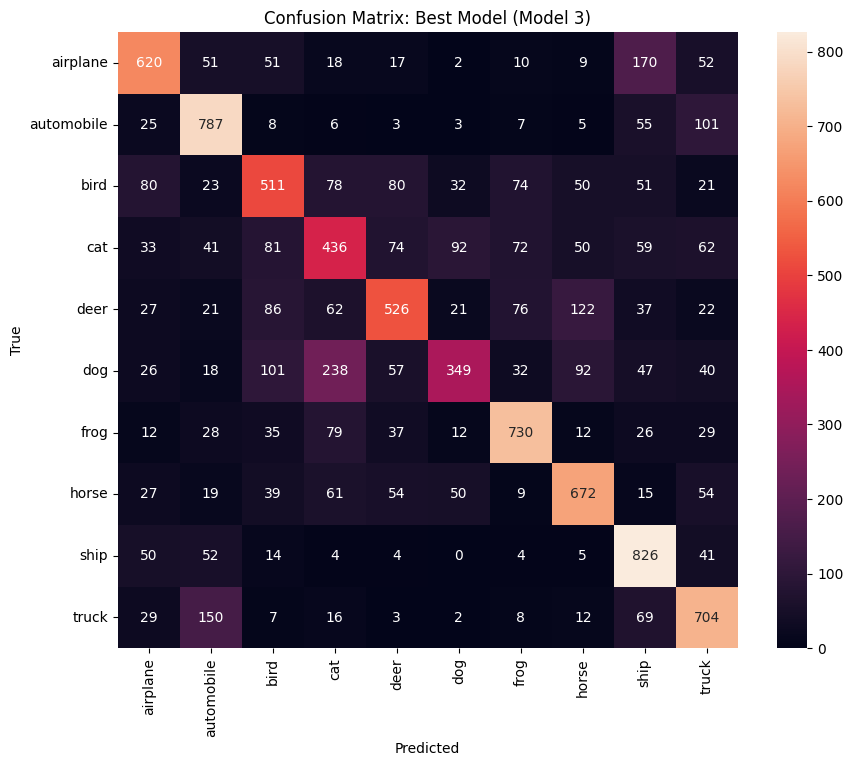

In [30]:
import seaborn as sns
cm = confusion_matrix(labels_best, preds_best)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=cf10_training_data.classes, yticklabels=cf10_training_data.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix: Best Model (Model 3)')
plt.show()

In [31]:
cr = classification_report(labels_best, preds_best)
print(cr)

              precision    recall  f1-score   support

           0       0.67      0.62      0.64      1000
           1       0.66      0.79      0.72      1000
           2       0.55      0.51      0.53      1000
           3       0.44      0.44      0.44      1000
           4       0.62      0.53      0.57      1000
           5       0.62      0.35      0.45      1000
           6       0.71      0.73      0.72      1000
           7       0.65      0.67      0.66      1000
           8       0.61      0.83      0.70      1000
           9       0.63      0.70      0.66      1000

    accuracy                           0.62     10000
   macro avg       0.62      0.62      0.61     10000
weighted avg       0.62      0.62      0.61     10000



To get all the info needed

In [32]:
#Getting results for three models

def print_model_summary(name, history):

    final_train_accuracy = history['training_accuracy'][-1]
    final_validation_accuracy = history['validation_accuracy'][-1]

    best_val_accuracy = max(history['validation_accuracy'])
    best_epoch = history['validation_accuracy'].index(best_val_accuracy) + 1  
    
    print(f"--- {name}'s Summary ---")
    print(f'Final Training Accuracy: {final_train_accuracy:.2f}%')
    print(f'Final Validation Accuracy: {final_validation_accuracy:.2f}%')
    print(f"Best Validation Accuracy: {best_val_accuracy:.2f}% (at Epoch {best_epoch})")



In [38]:
print_model_summary("CIFAR10_LeNet", history_1)
print_model_summary("CIFAR10_model_1 (Dropout)", history_2)
print_model_summary("CIFAR10_model_2 (BatchNorm)", history_3)

--- CIFAR10_LeNet's Summary ---
Final Training Accuracy: 80.36%
Final Validation Accuracy: 56.88%
Best Validation Accuracy: 59.06% (at Epoch 14)
--- CIFAR10_model_1 (Dropout)'s Summary ---
Final Training Accuracy: 51.58%
Final Validation Accuracy: 47.09%
Best Validation Accuracy: 48.04% (at Epoch 16)
--- CIFAR10_model_2 (BatchNorm)'s Summary ---
Final Training Accuracy: 85.66%
Final Validation Accuracy: 60.75%
Best Validation Accuracy: 63.39% (at Epoch 2)


In [39]:
def training_history_plot(name, history):
    epochs = range(1, len(history['training_loss']) + 1)

    plt.figure(figsize=(12,5))

    # plotting loss
    
    plt.subplot(1,2,1)
    plt.plot(epochs, history['training_loss'], 'r-', label='Training Loss' )
    plt.plot(epochs, history['validation_loss'], 'b-', label='Validation Loss' )
    plt.title(f'{name}: Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # plotting accuracy

    plt.subplot(1,2,2)
    plt.plot(epochs, history['training_accuracy'], 'r-', label='Training Accuracy' )
    plt.plot(epochs, history['validation_accuracy'], 'b-', label='Validation Accuracy' )
    plt.title(f'{name}: Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()


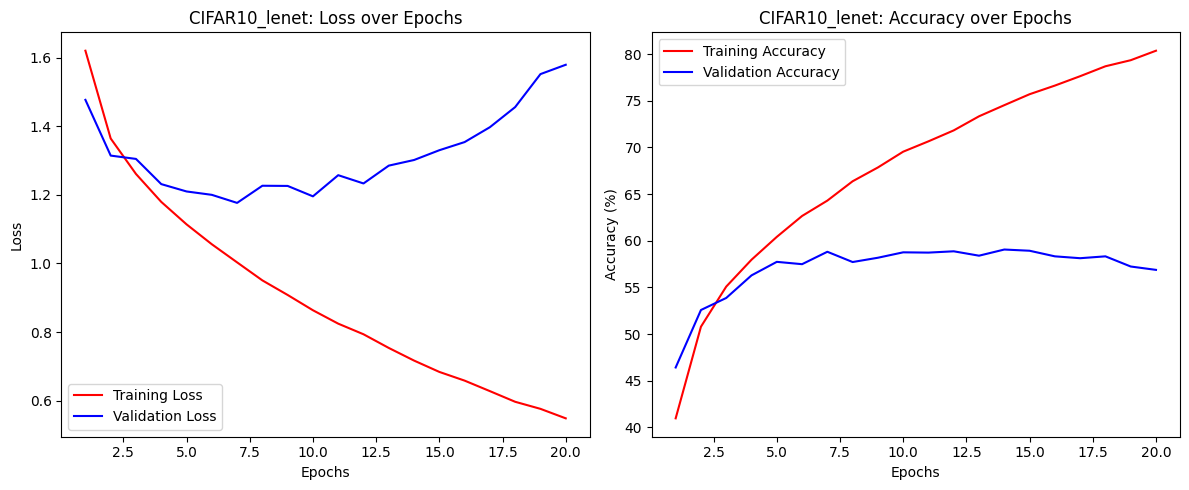

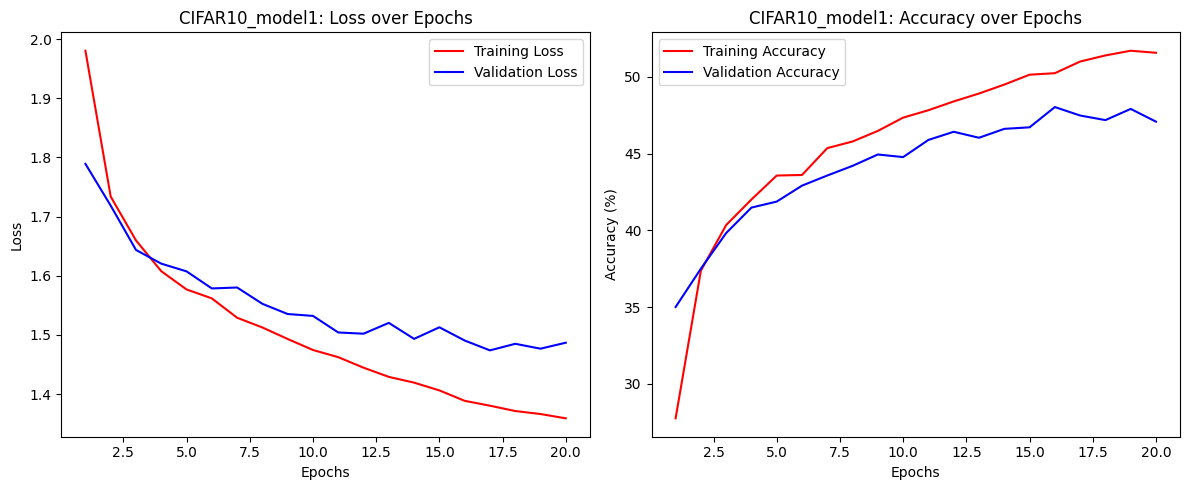

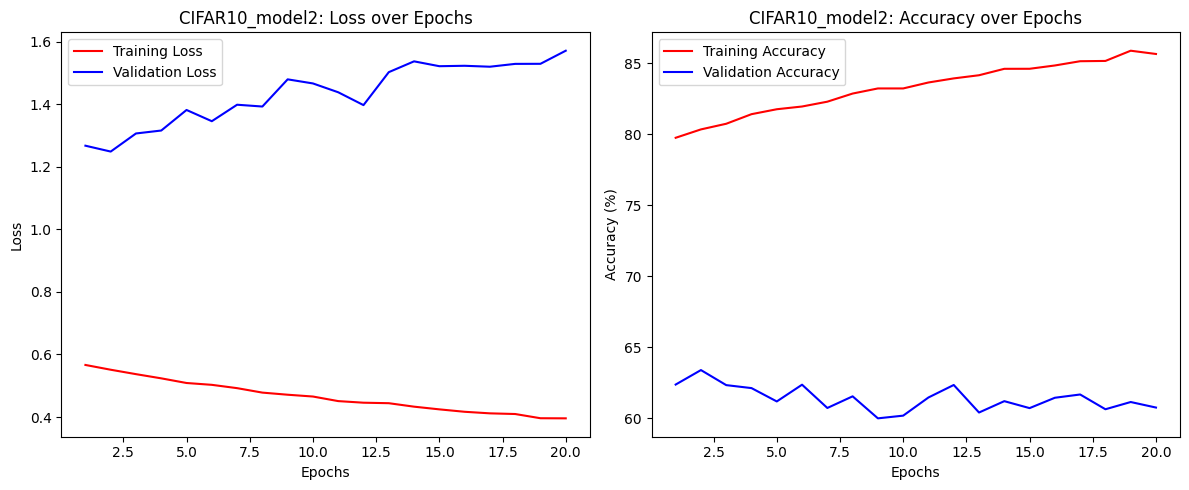

In [40]:
training_history_plot("CIFAR10_lenet", history_1)
training_history_plot("CIFAR10_model1", history_2)
training_history_plot("CIFAR10_model2", history_3)

In [41]:
def run_full_training_validate_choice1(model, train_loader, val_loader, epochs = 20):
    current_lr = 0.001
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr  = current_lr)
    
    history = {"training_loss": [], "training_accuracy": [], "validation_loss": [], "validation_accuracy": [], 'lr_history': []}
    print("---Training and Validation has started---")
    
    for epoch in range(epochs):
        
        
        if epoch % 5 == 0 and epoch > 0:
            current_lr = current_lr / 2
            for param_group in optimizer.param_groups:
                param_group['lr'] = current_lr
            
        history['lr_history'].append(current_lr)
        train_loss, train_accuracy = train_one_epoch(model, training_loader, optimizer, criterion)
            
        val_loss, val_accuracy = validate(model, val_loader, criterion)

        print(f"Epoch {epoch+1}, Training Loss : {train_loss}, Training Accuracy: {train_accuracy}")
        print(f"Epoch {epoch+1}, Validation Loss : {val_loss}, Validation Accuracy: {val_accuracy}")
        print(f'lr: {current_lr:.6f}')
        

        history['training_loss'].append(train_loss)
        history['training_accuracy'].append(train_accuracy)
        history['validation_loss'].append(val_loss)
        history['validation_accuracy'].append(val_accuracy)
    return history



In [42]:
history = run_full_training_validate_choice1(CIFAR10_pretrained, training_loader, validation_loader)

---Training and Validation has started---
Epoch 1, Training Loss : 0.7084217340230942, Training Accuracy: 74.6
Epoch 1, Validation Loss : 1.1814733398036834, Validation Accuracy: 61.95
lr: 0.001000
Epoch 2, Training Loss : 0.6934729556918144, Training Accuracy: 75.4175
Epoch 2, Validation Loss : 1.2136920262068605, Validation Accuracy: 61.050000000000004
lr: 0.001000
Epoch 3, Training Loss : 0.6715267172694206, Training Accuracy: 75.9975
Epoch 3, Validation Loss : 1.3541904369863078, Validation Accuracy: 57.82000000000001
lr: 0.001000
Epoch 4, Training Loss : 0.6533086786508561, Training Accuracy: 76.5575
Epoch 4, Validation Loss : 1.3945161174661436, Validation Accuracy: 57.68
lr: 0.001000
Epoch 5, Training Loss : 0.6405769110679627, Training Accuracy: 77.235
Epoch 5, Validation Loss : 1.2470930359614925, Validation Accuracy: 61.89
lr: 0.001000
Epoch 6, Training Loss : 0.5562845532298089, Training Accuracy: 80.34
Epoch 6, Validation Loss : 1.2198926993071462, Validation Accuracy: 62.4

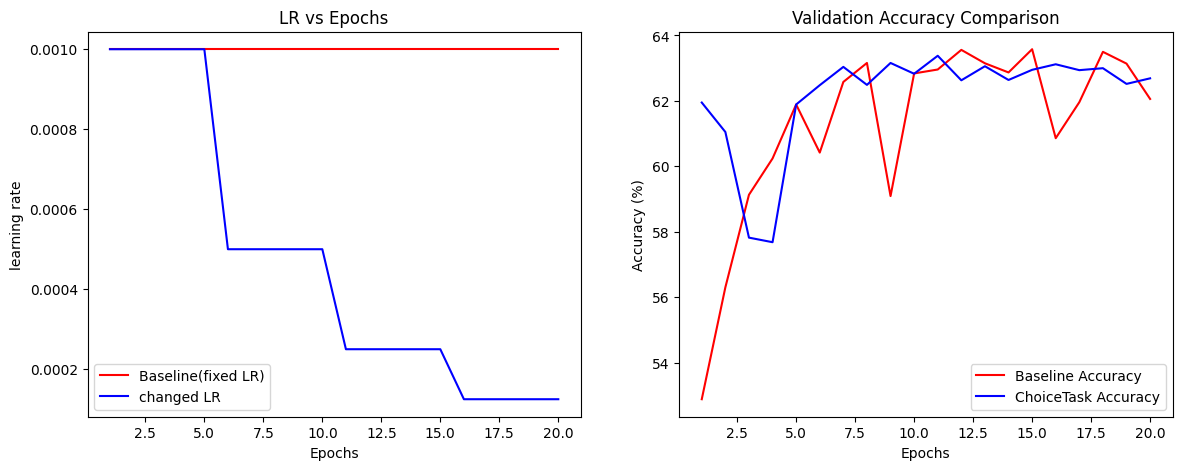

In [43]:

def plot_lr(history1, history2):
    epochs = range(1, len(history2['training_loss']) + 1)

    plt.figure(figsize = (14,5))

    plt.subplot(1,2,1)
    plt.plot(epochs, [0.001]* len(epochs), 'r-', label = 'Baseline(fixed LR)')
    if 'lr_history' in history2:
        plt.plot(epochs, history2['lr_history'], 'b-', label = 'changed LR')

    plt.title('LR vs Epochs')
    plt.xlabel("Epochs")
    plt.ylabel('learning rate')
    plt.legend()


    plt.subplot(1,2,2)
    plt.plot(epochs, history1['validation_accuracy'], 'r-', label='Baseline Accuracy' )
    plt.plot(epochs, history2['validation_accuracy'], 'b-', label='ChoiceTask Accuracy' )
    plt.title('Validation Accuracy Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()

plot_lr(history_pretrained, history)

Choice 5

In [44]:
# Defining Augmentation Transformation
print(1)
augmentation_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding= 4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
                           


])

# Create Augmented Training dataset

cf10_train_augmented = datasets.CIFAR10(root='data', train = True, download=True, transform= augmentation_transform)

train_size = 40000
val_size = 10000

cf10_aug_subset, _ = random_split(cf10_train_augmented, [train_size, val_size])

aug_training_loader = torch.utils.data.DataLoader(cf10_aug_subset, batch_size = 32, shuffle = True)


1


In [45]:
model_choice5 = Model3().to(device)

history_choice5 = run_full_training_validate(model_choice5, aug_training_loader, validation_loader)

---Training and Validation has started---
Epoch 1, Training Loss : 1.7163879017829895, Training Accuracy: 36.9825
Epoch 1, Validation Loss : 1.9011018588520086, Validation Accuracy: 32.85
Epoch 2, Training Loss : 1.4870422297000885, Training Accuracy: 46.32
Epoch 2, Validation Loss : 1.5064656189836252, Validation Accuracy: 46.39
Epoch 3, Training Loss : 1.3894985021591186, Training Accuracy: 50.0625
Epoch 3, Validation Loss : 1.2377398994784006, Validation Accuracy: 55.35
Epoch 4, Training Loss : 1.326314670419693, Training Accuracy: 52.61749999999999
Epoch 4, Validation Loss : 1.1561851849952065, Validation Accuracy: 57.95
Epoch 5, Training Loss : 1.2721714604377747, Training Accuracy: 54.2925
Epoch 5, Validation Loss : 1.373206890810031, Validation Accuracy: 51.43
Epoch 6, Training Loss : 1.2408173513412475, Training Accuracy: 55.67999999999999
Epoch 6, Validation Loss : 1.1680676560051524, Validation Accuracy: 58.19
Epoch 7, Training Loss : 1.2106024714946746, Training Accuracy: 56

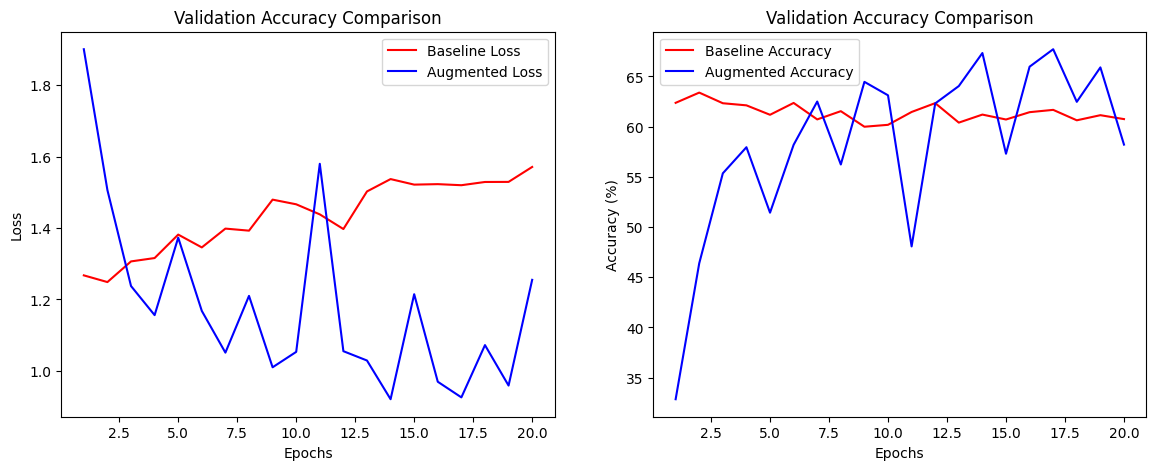

In [46]:
epochs = range(1, len(history_choice5['training_loss']) + 1)

plt.figure(figsize = (14,5))

plt.subplot(1,2,1)
plt.plot(epochs, history_3['validation_loss'], 'r-', label='Baseline Loss' )
plt.plot(epochs, history_choice5['validation_loss'], 'b-', label='Augmented Loss' )
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()


plt.subplot(1,2,2)
plt.plot(epochs, history_3['validation_accuracy'], 'r-', label='Baseline Accuracy' )
plt.plot(epochs, history_choice5['validation_accuracy'], 'b-', label='Augmented Accuracy' )
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

In [ ]:
# tsne
def tsne_embedding(model, loader, device, num_samples):
    model.eval()
    embeddings = []
    labels = []

    with torch.no_grad():
        for i, (images, targets) in enumerate(loader):
            images = images.to(device)
            X = images
            X = F.relu(model.bn1(model.conv1(X)))
            X = F.max_pool2d(X, (2,2))
            

            X = F.relu(model.bn2(model.conv2(X)))
            X = F.max_pool2d(X, (2,2))
        

            X = X.flatten(1)

            X = F.relu(model.bn3(model.fc1(X)))

            #tsne
            layer_output = F.relu(model.fc2(X)) #before the last layer
            embeddings.extend(layer_output.cpu().numpy())
            labels.extend(targets.numpy())

            if len(embeddings)>= num_samples:
                break
            
    return np.array(embeddings), np.array(labels)
            
            # X = model.fc3(X)

num_samples = 1000
features, true_labels = tsne_embedding(model_choice5, training_loader, device, num_samples )
tsne = TSNE(n_components=2, perplexity=30, max_iter= 1000 random_state=42)
two_d_embeddings = tsne.fit_transform(features)


plt.figure(figsize=(12, 8))
classes = cf10_training_data.classes
for i in range(10):
    indices = np.where(true_labels == i)
    plt.scatter(two_d_embeddings[indices, 0], two_d_embeddings[indices, 1], label=classes[i], alpha=0.7)

plt.legend()
plt.title("t-SNE Visualization: Features before Output Layer (FC2)")
plt.show()



TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'